# DISSERTAÇÃO DE MESTRADO

@author: Guilherme Nogueira

### IMPORTAÇÕES

In [39]:
# Gerais
import numpy as np
import pandas as pd

# Gráficos
import numpy as np
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Localização
import locale
locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')

'pt_BR.UTF-8'

## LENDO A MIP E EXTRAINDO VARIÁVEIS

### Leitura das Abas

In [2]:
ARQUIVO = "..\\data\\mips\\48008000133202507_Ian_Anexo.xlsx"

raw_monetario    = pd.read_excel(ARQUIVO, sheet_name="Fluxos Monetários",  header=None)
raw_energia      = pd.read_excel(ARQUIVO, sheet_name="Fluxos Energia",     header=None)
raw_en_demfinal  = pd.read_excel(ARQUIVO, sheet_name="Energia Demanda Final", header=None)
raw_emp_setorial = pd.read_excel(ARQUIVO, sheet_name="Emprego Setorial",   header=None)
raw_emprego      = pd.read_excel(ARQUIVO, sheet_name="Emprego",            header=None)
raw_energia_tab  = pd.read_excel(ARQUIVO, sheet_name="Energia",            header=None)

### Nome dos Setores

In [3]:
N = 73  # número de setores

# Linha 5 (índice 5): nomes; linha 4 (índice 4): códigos S01..S73
# Colunas 3..75 correspondem aos setores
sector_names = list(raw_monetario.iloc[5, 3:3+N])
sector_codes = list(raw_monetario.iloc[4, 3:3+N])
sectors = pd.Index(sector_codes, name="setor")

### Matriz Z  

- Fluxos Intermediários 
- Tamanho: N x N

In [ ]:
Z_raw = raw_monetario.iloc[7:7+N, 3:3+N].values.astype(float)
Z = pd.DataFrame(Z_raw, index=sectors, columns=sectors)

### Demanda Final (x)

- (colunas 77..83)
- 77 = Exportações
- 78 = Governo
- 79 = ISFLSF
- 80 = Famílias
- 81 = FBCF
- 82 = Variação estoque
- 83 = Demanda Final Total

In [6]:
df_names = ["Exportacoes", "Consumo_Governo", "Consumo_ISFLSF",
            "Consumo_Familias", "FBCF", "Variacao_Estoque"]

# Apenas os componentes individuais vêm da MIP (não deriváveis)
y_raw = raw_monetario.iloc[7:7+N, 77:77+6].values.astype(float)
y = pd.DataFrame(y_raw, index=sectors, columns=df_names)

# valor da produção total (col 84)
x_raw = raw_monetario.iloc[7:7+N, 84].values.astype(float)
x = pd.Series(x_raw, index=sectors, name="Producao_Total")

### Valor Adicionado (VA)

- linhas abaixo dos setores
- Referência pelas labels da col 0

In [7]:
# Mapeamento: código -> linha no DataFrame
va_map = {
    "R10": "Remuneracoes",
    "R11": "Salarios",
    "R12": "Contrib_Sociais_Efetivas",
    "R13": "Contrib_Sociais_Imputadas",
    "N2":  "EOB_Rendimento_Misto",
    "N0":  "VA_Custo_Fatores",
    "R22": "Outros_Impostos_Producao",
    "R32": "Outros_Subsidios_Producao",
    "P10": "Valor_Producao",
}

va = {}
for i in range(len(raw_monetario)):
    cod = raw_monetario.iloc[i, 0]
    if pd.notna(cod) and cod in va_map:
        vals = raw_monetario.iloc[i, 3:3+N].values.astype(float)
        va[va_map[cod]] = pd.Series(vals, index=sectors)

VA = pd.DataFrame(va)

### Demanda Final Total (f)

In [42]:
# f: demanda final = soma dos componentes individuais (identidade contábil)
y["Demanda_Final_Total"] = y.sum(axis=1)

f = y["Demanda_Final_Total"].rename("Demanda_Final")

### Consumo Intermediário

In [9]:
# Nota: CI da MIP inclui impostos sobre produtos (ICMS, IPI, outros IIL)
# que estão fora de Z — por isso CI é lido diretamente da MIP abaixo.

# CI: lido da MIP pois inclui impostos não contidos em Z
for i in range(len(raw_monetario)):
    lab = str(raw_monetario.iloc[i, 1]).strip()
    if "CONSUMO INTERMEDIÁRIO" in lab and "Total" not in lab:
        CI = pd.Series(raw_monetario.iloc[i, 3:3+N].values.astype(float),
                       index=sectors, name="CI_Total")
        break

# VAB/PIB = x - CI  (valor adicionado bruto = produção - consumo intermediário)
VA["VAB_PIB"] = (x - CI).rename("VAB_PIB")

### Fator trabalho

In [10]:
# Fator trabalho (última linha da aba)
for i in range(len(raw_monetario)):
    lab = str(raw_monetario.iloc[i, 1]).strip()
    if "Fator trabalho" in lab:
        emp_vals = raw_monetario.iloc[i, 3:3+N].values.astype(float)
        emprego_mip = pd.Series(emp_vals, index=sectors, name="Ocupacoes")
        break

### Matriz A  e  Leontief 

- (I - A)^-1

In [11]:
x_inv = np.where(x.values != 0, 1.0 / x.values, 0.0)
A_raw = Z.values * x_inv[np.newaxis, :] # A = Z . diag(x)^-1
A = pd.DataFrame(A_raw, index=sectors, columns=sectors)

I = np.eye(N)
L_raw = np.linalg.inv(I - A_raw)
L = pd.DataFrame(L_raw, index=sectors, columns=sectors)

### Matriz de Energia  e  (produtos x setores)

In [12]:
# Linha 3: cabeçalho produtos; linha 5: unidade; linhas 6..11: dados
energy_products = list(raw_energia.iloc[3:5, 1].ffill())
en_labels = raw_energia.iloc[6:, 1].values          # nomes dos produtos
en_data   = raw_energia.iloc[6:, 3:3+N].values.astype(float)
en_rows   = [str(v).strip() for v in en_labels if pd.notna(v)]

E_raw = raw_energia.iloc[6:, 3:3+N].values.astype(float)
en_index = pd.Index([str(v).strip() for v in raw_energia.iloc[6:, 1]], name="produto_energia")
E = pd.DataFrame(E_raw, index=en_index, columns=sectors)

# Energia total por setor (tep x 1000)
E_total = E.sum(axis=0).rename("Energia_Total_tep1000")

### Emprego Detalhado

In [13]:
emp_df = raw_emprego.copy()
emp_df.columns = raw_emprego.iloc[0]
emp_df = emp_df.iloc[1:].reset_index(drop=True)
emp_df.columns = ["id", "descricao", "Informal", "Formal", "Total"]
emp_df[["Informal","Formal","Total"]] = emp_df[["Informal","Formal","Total"]].astype(float)
emp_df.index = sectors

## COEFICIENTES

In [34]:
e_coef  = emp_df["Total"] / x          # ocupações / R$ mi
en_coef = E_total / x                  # tep(x1000) / R$ mi

e_coef.name  = "Coef_Emprego"
en_coef.name = "Coef_Energia"

# Saída csv
n = len(sectors)

# IDs dos setores energéticos conforme EPE/FIPE - Nota Técnica EPE/DEA/SEE/013/2023
ids_energia = [5, 19, 20, 21, 22, 40, 41, 42, 43]

## MULTIPLICADORES

### Multiplicador de Produção

In [23]:
# Multiplicador de produção (tipo I): soma coluna de L

M_prod = L.sum(axis=0).rename("Mult_Producao_TipoI")

df_multi_producao = pd.DataFrame({
    "ID":         range(1, n + 1),
    "Setor":      sector_names,
    "M_Producao": M_prod.values,
}).sort_values("M_Producao", ascending=False).reset_index(drop=True)

df_multi_producao.index = range(1, len(df_multi_producao) + 1)

res_df_multi_producao = df_multi_producao.sort_values("M_Producao", ascending=False)

# arredondar para 2 casas e formato brasileiro (ponto → vírgula)
res_df_multi_producao["M_Producao"] = res_df_multi_producao["M_Producao"].map(lambda x: f"{x:.2f}".replace(".", ","))

res_df_multi_producao.head(10).to_csv("..\\data\\cenarios\\base\\cen_base_multi_producao.csv", index=False, sep=";", encoding="utf-8-sig")

print("🔹 Setores com os Maiores Multiplicadores de Produção:")
print(res_df_multi_producao.head(10)[["ID", "Setor", "M_Producao"]].to_string(index=False))

🔹 Setores com os Maiores Multiplicadores de Produção:
 ID                                                                      Setor M_Producao
 21                                                                  Coquerias       3,53
  8   Abate e produtos de carne, inclusive os produtos do laticínio e da pesca       2,48
  9                                              Fabricação e refino de açúcar       2,38
 22                                              Fabricação de biocombustíveis       2,32
 19                                                      Derivados de petróleo       2,30
 10                                                Outros produtos alimentares       2,30
 20                                                                  Biodiesel       2,29
 35                 Fabricação de automóveis, caminhões e ônibus, exceto peças       2,27
 25 Fabricação de produtos de limpeza, cosméticos/perfumaria e higiene pessoal       2,14
 12                                           

In [35]:
# Produção
res_energia_prod = res_df_multi_producao[res_df_multi_producao["ID"].isin(ids_energia)]
print("🔹 Multiplicadores de Produção - Setores Energéticos:")
print(res_energia_prod[["ID", "Setor", "M_Producao"]].to_string(index=False))

🔹 Multiplicadores de Produção - Setores Energéticos:
 ID                                                        Setor M_Producao
 21                                                    Coquerias       3,53
 22                                Fabricação de biocombustíveis       2,32
 19                                        Derivados de petróleo       2,30
 20                                                    Biodiesel       2,29
 40                     Geração centralizada de energia elétrica       2,01
 41                      Geração distribuída de energia elétrica       2,00
  5 Extração de petróleo e gás, inclusive as atividades de apoio       1,67
 43                                                  Gás Natural       1,61
 42                                                  Transmissão       1,49


### Multiplicador de Emprego

In [24]:
# Multiplicador de emprego: e_coef . L
M_emp = e_coef.values @ L.values
M_emp = pd.Series(M_emp, index=sectors, name="Mult_Emprego")

df_multi_emprego = pd.DataFrame({
    "ID":          range(1, n + 1),
    "Setor":       sector_names,
    "Coef_Emprego": e_coef.values,
    "M_Emprego":   M_emp.values,
}).sort_values("M_Emprego", ascending=False).reset_index(drop=True)

df_multi_emprego.index = range(1, len(df_multi_emprego) + 1)

res_df_multi_emprego = df_multi_emprego.sort_values("M_Emprego", ascending=False)

# arredondar para 2 casas e formato brasileiro (ponto → vírgula)
res_df_multi_emprego["Coef_Emprego"] = res_df_multi_emprego["Coef_Emprego"].map(lambda x: f"{x:.2f}".replace(".", ","))
res_df_multi_emprego["M_Emprego"]    = res_df_multi_emprego["M_Emprego"].map(lambda x: f"{x:.2f}".replace(".", ","))

res_df_multi_emprego.to_csv("..\\data\\cenarios\\base\\cen_base_multi_emprego.csv", index=False, sep=";", encoding="utf-8-sig")

print("🔹 Setores com os Maiores Multiplicadores de Emprego:")
print(res_df_multi_emprego.head(10)[["ID", "Setor", "Coef_Emprego", "M_Emprego"]].to_string(index=False))

🔹 Setores com os Maiores Multiplicadores de Emprego:
 ID                                                                    Setor Coef_Emprego M_Emprego
 73                                                      Serviços domésticos        88,16     88,16
  2                                   Pecuária, inclusive o apoio à pecuária        38,77     45,94
 14                         Confecção de artefatos do vestuário e acessórios        25,24     33,52
 72                     Organizações associativas e outros serviços pessoais        26,19     31,89
 71                        Atividades artísticas, criativas e de espetáculos        27,82     31,68
 53                                                              Alimentação        20,30     26,97
  3                                  Produção florestal; pesca e aquicultura        21,15     24,54
  8 Abate e produtos de carne, inclusive os produtos do laticínio e da pesca         2,62     23,62
 68                                            

In [36]:
# Emprego
res_energia_emp = res_df_multi_emprego[res_df_multi_emprego["ID"].isin(ids_energia)]
print("🔹 Multiplicadores de Emprego - Setores Energéticos:")
print(res_energia_emp[["ID", "Setor", "Coef_Emprego", "M_Emprego"]].to_string(index=False))

🔹 Multiplicadores de Emprego - Setores Energéticos:
 ID                                                        Setor Coef_Emprego M_Emprego
 22                                Fabricação de biocombustíveis         1,80     14,48
 21                                                    Coquerias         0,08      5,47
 19                                        Derivados de petróleo         0,04      4,63
 20                                                    Biodiesel         0,25      4,43
  5 Extração de petróleo e gás, inclusive as atividades de apoio         0,22      4,18
 41                      Geração distribuída de energia elétrica         0,47      3,96
 42                                                  Transmissão         0,74      3,93
 40                     Geração centralizada de energia elétrica         0,44      3,89
 43                                                  Gás Natural         0,68      2,81


### Multiplicador de Renda

In [29]:
# Coeficiente de Renda (Remunerações por unidade de produção)
w_coef = VA["Remuneracoes"] / x

# Multiplicador de Renda: w_coef . L
# w_j = Rem_j / x_j  →  quanto de massa salarial é gerado na economia por R$1 de demanda final no setor j
M_renda = w_coef.values @ L.values

M_renda = pd.Series(M_renda, index=sectors, name="Mult_Renda")

df_multi_renda = pd.DataFrame({
    "ID":          range(1, n + 1),
    "Setor":       sector_names,
    "Coef_Renda":  w_coef.values,
    "M_Renda":     M_renda.values,
}).sort_values("M_Renda", ascending=False).reset_index(drop=True)

df_multi_renda.index = range(1, len(df_multi_renda) + 1)

res_df_multi_renda = df_multi_renda.sort_values("M_Renda", ascending=False)

# arredondar para 2 casas e formato brasileiro (ponto → vírgula)
res_df_multi_renda["Coef_Renda"] = res_df_multi_renda["Coef_Renda"].map(lambda x: f"{x:.2f}".replace(".", ","))
res_df_multi_renda["M_Renda"]    = res_df_multi_renda["M_Renda"].map(lambda x: f"{x:.2f}".replace(".", ","))

res_df_multi_renda.head(10).to_csv("..\\data\\cenarios\\base\\cen_base_multi_renda.csv", index=False, sep=";", encoding="utf-8-sig")

print("🔹 Setores com os Maiores Multiplicadores de Renda:")
print(res_df_multi_renda.head(10)[["ID", "Setor", "Coef_Renda", "M_Renda"]].to_string(index=False))

🔹 Setores com os Maiores Multiplicadores de Renda:
 ID                                                                     Setor Coef_Renda M_Renda
 73                                                       Serviços domésticos       1,00    1,00
 67                                                          Educação pública       0,80    0,86
 65                        Atividades de vigilância, segurança e investigação       0,72    0,78
 69                                                             Saúde pública       0,63    0,75
 68                                                          Educação privada       0,63    0,72
 66                         Administração pública, defesa e seguridade social       0,62    0,72
 64               Outras atividades administrativas e serviços complementares       0,45    0,56
 54                                     Edição e edição integrada à impressão       0,38    0,55
 52                                                                Alojament

In [37]:
# Renda
res_energia_renda = res_df_multi_renda[res_df_multi_renda["ID"].isin(ids_energia)]
print("🔹 Multiplicadores de Renda - Setores Energéticos:")
print(res_energia_renda[["ID", "Setor", "Coef_Renda", "M_Renda"]].to_string(index=False))

🔹 Multiplicadores de Renda - Setores Energéticos:
 ID                                                        Setor Coef_Renda M_Renda
 22                                Fabricação de biocombustíveis       0,13    0,32
  5 Extração de petróleo e gás, inclusive as atividades de apoio       0,07    0,21
 21                                                    Coquerias       0,01    0,21
 40                     Geração centralizada de energia elétrica       0,06    0,21
 42                                                  Transmissão       0,10    0,21
 41                      Geração distribuída de energia elétrica       0,05    0,19
 43                                                  Gás Natural       0,09    0,18
 19                                        Derivados de petróleo       0,02    0,18
 20                                                    Biodiesel       0,02    0,17


### Multiplicadores de Valor Adicionado (PIB)

In [ ]:
# Coeficiente de VA (VA por unidade de produção)
v_coef = VA["VAB_PIB"] / x

# Multiplicador de VA (PIB): v_coef . L
# v_j = VAB_j / x_j  →  quanto de VA é gerado na economia por R$1 de demanda final no setor j
M_va = v_coef.values @ L.values

M_va = pd.Series(M_va, index=sectors, name="Mult_VA")

df_multi_va = pd.DataFrame({
    "ID":      range(1, n + 1),
    "Setor":   sector_names,
    "Coef_VA": v_coef.values,
    "M_VA":    M_va.values,
}).sort_values("M_VA", ascending=False).reset_index(drop=True)

df_multi_va.index = range(1, len(df_multi_va) + 1)

res_df_multi_va = df_multi_va.sort_values("M_VA", ascending=False)

# arredondar para 2 casas e formato brasileiro (ponto → vírgula)
res_df_multi_va["Coef_VA"] = res_df_multi_va["Coef_VA"].map(lambda x: f"{x:.2f}".replace(".", ","))
res_df_multi_va["M_VA"]    = res_df_multi_va["M_VA"].map(lambda x: f"{x:.2f}".replace(".", ","))

res_df_multi_va.head(10).to_csv("..\\data\\cenarios\\base\\cen_base_multi_pib.csv", index=False, sep=";", encoding="utf-8-sig")

print("🔹 Setores com os Maiores Multiplicadores de PIB:")
print(res_df_multi_va.head(10)[["ID", "Setor", "Coef_VA", "M_VA"]].to_string(index=False))

In [ ]:
# VA
res_energia_va = res_df_multi_va[res_df_multi_va["ID"].isin(ids_energia)]
print("🔹 Multiplicadores de VA - Setores Energéticos:")
print(res_energia_va[["ID", "Setor", "Coef_VA", "M_VA"]].to_string(index=False))

### Encadeamentos (backward & forward linkages)

In [38]:
# Rasmussen-Hirschman
L_mean = L.values.mean()

# Backward: média coluna / média geral
BL = L.mean(axis=0) / L_mean
BL.name = "Backward_Linkage"

# Forward (Ghosh): H = (I - F)^-1  onde F = diag(x)^-1 . Z
F_raw = x_inv[:, np.newaxis] * Z.values
H_raw = np.linalg.inv(I - F_raw)
H = pd.DataFrame(H_raw, index=sectors, columns=sectors)
FL = H.mean(axis=1) / H.values.mean()
FL.name = "Forward_Linkage"

# Monta dataframe de encadeamentos
df_linkages = pd.DataFrame({
    "ID":    range(1, n + 1),
    "Setor": sector_names,
    "BL":    BL.values,
    "FL":    FL.values,
})

df_linkages["is_energy"] = df_linkages["ID"].isin(ids_energia)

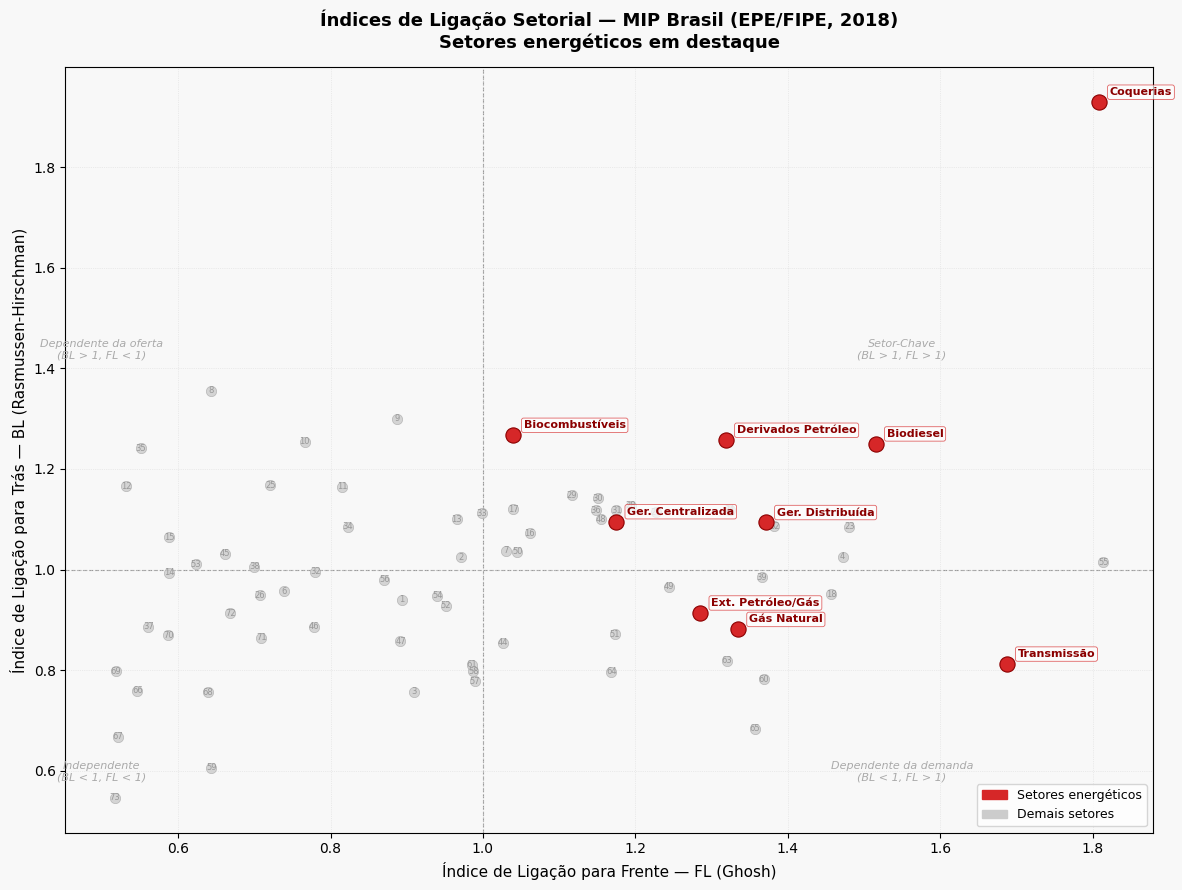

Salvo: encadeamentos_setores_energeticos.png


In [40]:
# ── Figura ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
ax.set_facecolor("#f8f8f8")
fig.patch.set_facecolor("#f8f8f8")

# Linhas de corte (média = 1)
ax.axhline(1, color="#999999", linewidth=0.8, linestyle="--", zorder=1)
ax.axvline(1, color="#999999", linewidth=0.8, linestyle="--", zorder=1)

# Rótulos dos quadrantes
quad_kw = dict(fontsize=8, color="#aaaaaa", fontstyle="italic", ha="center")
ax.text(0.50, 1.42, "Dependente da oferta\n(BL > 1, FL < 1)", **quad_kw)
ax.text(1.55, 1.42, "Setor-Chave\n(BL > 1, FL > 1)",  **quad_kw)
ax.text(0.50, 0.58, "Independente\n(BL < 1, FL < 1)",  **quad_kw)
ax.text(1.55, 0.58, "Dependente da demanda\n(BL < 1, FL > 1)", **quad_kw)

# Setores não energéticos — cinza
non_e = df_linkages[~df_linkages["is_energy"]]
ax.scatter(non_e["FL"], non_e["BL"],
           color="#cccccc", edgecolors="#aaaaaa", linewidths=0.5,
           s=55, zorder=2, alpha=0.8)

# IDs nos pontos não energéticos
for _, row in non_e.iterrows():
    ax.annotate(str(int(row["ID"])),
                xy=(row["FL"], row["BL"]),
                fontsize=6, color="#999999",
                ha="center", va="center", zorder=3)

# Setores energéticos — vermelho destacado
ene = df_linkages[df_linkages["is_energy"]]
ax.scatter(ene["FL"], ene["BL"],
           color="#d62728", edgecolors="#8b0000", linewidths=0.8,
           s=120, zorder=4)

# Labels dos setores energéticos com nome curto
nomes_curtos = {
    5:  "Ext. Petróleo/Gás",
    19: "Derivados Petróleo",
    20: "Biodiesel",
    21: "Coquerias",
    22: "Biocombustíveis",
    40: "Ger. Centralizada",
    41: "Ger. Distribuída",
    42: "Transmissão",
    43: "Gás Natural",
}

for _, row in ene.iterrows():
    nome = nomes_curtos.get(int(row["ID"]), str(int(row["ID"])))
    ax.annotate(nome,
                xy=(row["FL"], row["BL"]),
                xytext=(8, 5), textcoords="offset points",
                fontsize=8, color="#8b0000", fontweight="bold",
                zorder=5,
                bbox=dict(boxstyle="round,pad=0.2", fc="white",
                          ec="#d62728", alpha=0.7, linewidth=0.6))

# Eixos e título
ax.set_xlabel("Índice de Ligação para Frente — FL (Ghosh)", fontsize=11)
ax.set_ylabel("Índice de Ligação para Trás — BL (Rasmussen-Hirschman)", fontsize=11)
ax.set_title("Índices de Ligação Setorial — MIP Brasil (EPE/FIPE, 2018)\nSetores energéticos em destaque",
             fontsize=13, fontweight="bold", pad=14)

# Legenda
patch_e   = mpatches.Patch(color="#d62728", label="Setores energéticos")
patch_ne  = mpatches.Patch(color="#cccccc", label="Demais setores")
ax.legend(handles=[patch_e, patch_ne], fontsize=9, loc="lower right")

ax.grid(True, linestyle=":", linewidth=0.5, color="#dddddd", zorder=0)

plt.tight_layout()
plt.savefig("..\\data\\graphs\\encadeamentos_setores_energeticos.png", dpi=180, bbox_inches="tight")
plt.show()
print("Salvo: encadeamentos_setores_energeticos.png")

## CENÁRIOS

### Cenário Bio+El

In [65]:
# =============================================================================
#  CENÁRIO 1 — Versão 3: Choque Neutro com Preços Implícitos
#
#  Lógica:
#  1. Calcula preço implícito: p_j = fluxo_base_j / demanda_base_j
#  2. Calcula novo fluxo bruto: novo_fluxo_j = nova_demanda_j * p_j
#  3. Escala os novos fluxos para que o total monetário seja igual ao base
#     fator = sum(fluxo_base) / sum(novo_fluxo_bruto)
#     novo_fluxo_ajustado_j = novo_fluxo_bruto_j * fator
#  4. Δf_j = novo_fluxo_ajustado_j - fluxo_base_j  →  sum(Δf) ≈ 0
#
#  Interpretação: o gasto total em energia se mantém constante (em R$),
#  mas é redistribuído entre as fontes conforme a nova composição da matriz.
#  O efeito em produção/emprego/VA vem exclusivamente da diferença
#  nos multiplicadores de Leontief entre as fontes.
# =============================================================================

# ── Índices 0-based ───────────────────────────────────────────────────────────
i_S19 = 18
i_S20 = 19
i_S22 = 21
i_S40 = 39
i_S41 = 40
i_S43 = 42

# ── Cenário Base ──────────────────────────────────────────────────────────────
demanda_base = {
    i_S19: 56_168.35,
    i_S20:  3_474.00,
    i_S22: 15_717.54,
    i_S40:    163.14,
    i_S41:      6.13,
    i_S43:  1_946.32,
}

fluxo_base = {
    i_S19: 72_335.84,
    i_S20:  5_181.18,
    i_S22:    701.34,
    i_S40:     26.38,
    i_S41:      0.99,
    i_S43:  1_553.32,
}

# ── Nova demanda física — Cenário 1 ───────────────────────────────────────────
nova_demanda_cen1 = {
    i_S19:      0.00,
    i_S20: 39_327.71,
    i_S22: 37_175.30,
    i_S40:    932.65,
    i_S41:     35.90,
    i_S43:      0.00,
}

# ── Passo 1: preço implícito ──────────────────────────────────────────────────
preco = {idx: fluxo_base[idx] / demanda_base[idx] if demanda_base[idx] != 0 else 0.0
         for idx in demanda_base}

# ── Passo 2: novo fluxo bruto (sem ajuste) ────────────────────────────────────
novo_fluxo_bruto = {idx: nova_demanda_cen1[idx] * preco[idx] for idx in preco}

# ── Passo 3: fator de escala para neutralidade monetária ─────────────────────
total_base  = sum(fluxo_base.values())
total_bruto = sum(novo_fluxo_bruto.values())
fator       = total_base / total_bruto if total_bruto != 0 else 1.0

novo_fluxo_ajustado = {idx: v * fator for idx, v in novo_fluxo_bruto.items()}

# ── Validação ─────────────────────────────────────────────────────────────────
nomes = {
    i_S19: "S19 Derivados petróleo",
    i_S20: "S20 Biodiesel",
    i_S22: "S22 Etanol",
    i_S40: "S40 Elet. centralizada",
    i_S41: "S41 Elet. distribuída",
    i_S43: "S43 Gás Natural",
}

print("=" * 95)
print(f"{'Setor':<25} {'D_base':>10} {'F_base':>10} {'Preço':>6} {'D_cen1':>10} "
      f"{'F_bruto':>10} {'Fator':>6} {'F_ajust':>10}")
print("-" * 95)
for idx in demanda_base:
    print(f"{nomes[idx]:<25} "
          f"{demanda_base[idx]:>10.2f} "
          f"{fluxo_base[idx]:>10.2f} "
          f"{preco[idx]:>6.2f} "
          f"{nova_demanda_cen1[idx]:>10.2f} "
          f"{novo_fluxo_bruto[idx]:>10.2f} "
          f"{fator:>6.4f} "
          f"{novo_fluxo_ajustado[idx]:>10.2f}")
print("-" * 95)
print(f"{'TOTAL':<25} "
      f"{sum(demanda_base.values()):>10.2f} "
      f"{total_base:>10.2f} "
      f"{'':>6} "
      f"{sum(nova_demanda_cen1.values()):>10.2f} "
      f"{total_bruto:>10.2f} "
      f"{'':>6} "
      f"{sum(novo_fluxo_ajustado.values()):>10.2f}  ← deve = F_base total")
print("=" * 95)
print(f"\n  Fator de escala aplicado: {fator:.6f}")
print(f"  Total base:    R$ {total_base:,.2f} mi")
print(f"  Total bruto:   R$ {total_bruto:,.2f} mi")
print(f"  Total ajust.:  R$ {sum(novo_fluxo_ajustado.values()):,.2f} mi  (deve = total base)")

# ── Passo 4: Δf neutro ────────────────────────────────────────────────────────
delta_f_v3 = pd.Series(0.0, index=f.index)

for idx in novo_fluxo_ajustado:
    setor = sectors[idx]
    delta_f_v3[setor] = novo_fluxo_ajustado[idx] - fluxo_base[idx]

print(f"\n  Σ Δf (deve ≈ 0): {delta_f_v3.sum():.6f}")

# ── Modelo de Leontief ────────────────────────────────────────────────────────
delta_x_v3   = L @ delta_f_v3
x_cen1_v3    = x + delta_x_v3
delta_va_v3  = v_coef * delta_x_v3
delta_emp_v3 = e_coef * delta_x_v3

# ── DataFrame por setor ───────────────────────────────────────────────────────
df_cen1_v3 = pd.DataFrame({
    "ID":        range(1, N + 1),
    "Setor":     sector_names,
    "f_base":    f.values,
    "delta_f":   delta_f_v3.values,
    "f_cen1_v3": (f + delta_f_v3).values,
    "delta_x":   delta_x_v3.values,
    "x_cen1_v3": x_cen1_v3.values,
    "delta_va":  delta_va_v3.values,
    "delta_emp": delta_emp_v3.values,
}, index=sectors)

df_cen1_v3["emp_coeff"] = e_coef.values

Setor                         D_base     F_base  Preço     D_cen1    F_bruto  Fator    F_ajust
-----------------------------------------------------------------------------------------------
S19 Derivados petróleo      56168.35   72335.84   1.29       0.00       0.00 1.3197       0.00
S20 Biodiesel                3474.00    5181.18   1.49   39327.71   58653.99 1.3197   77403.31
S22 Etanol                  15717.54     701.34   0.04   37175.30    1658.82 1.3197    2189.07
S40 Elet. centralizada        163.14      26.38   0.16     932.65     150.81 1.3197     199.02
S41 Elet. distribuída           6.13       0.99   0.16      35.90       5.80 1.3197       7.65
S43 Gás Natural              1946.32    1553.32   0.80       0.00       0.00 1.3197       0.00
-----------------------------------------------------------------------------------------------
TOTAL                       77475.48   79799.05          77471.56   60469.41          79799.05  ← deve = F_base total

  Fator de escala aplica

In [66]:
# ── Resultados agregados ──────────────────────────────────────────────────────
print("\n📊 RESULTADOS — Cenário 1 (Versão 3: Choque Neutro)")
print(f"  Σ Δf  (choque líquido, R$ mi): {delta_f_v3.sum():>12.6f}  ← ≈ 0")
print(f"  Σ Δx  (Δ produção,     R$ mi): {delta_x_v3.sum():>12.2f}")
print(f"  Σ ΔVA (Δ val. adic.,   R$ mi): {delta_va_v3.sum():>12.2f}")
print(f"  Σ Δemp (Δ empregos):           {delta_emp_v3.sum():>12.0f}")


📊 RESULTADOS — Cenário 1 (Versão 3: Choque Neutro)
  Σ Δf  (choque líquido, R$ mi):     0.000000  ← ≈ 0
  Σ Δx  (Δ produção,     R$ mi):        76.38
  Σ ΔVA (Δ val. adic.,   R$ mi):       148.24
  Σ Δemp (Δ empregos):                   2393


In [68]:
# =============================================================================
#  TABELAS RESUMO — Produção e VA
# =============================================================================

cen1_v3_num = df_cen1_v3[["ID", "Setor", "delta_x", "delta_va"]].copy()
cen1_v3_num["delta_x"]  = pd.to_numeric(cen1_v3_num["delta_x"],  errors="coerce")
cen1_v3_num["delta_va"] = pd.to_numeric(cen1_v3_num["delta_va"], errors="coerce")

cen1_v3_sorted = cen1_v3_num.sort_values("delta_x", ascending=False)

top10_num = cen1_v3_sorted.head(10)
bot10_num = cen1_v3_sorted.tail(10).sort_values("delta_x", ascending=True)

def formatar(df):
    out = df.copy()
    out["delta_x"]  = out["delta_x"].map(lambda v: f"{v:.2f}")
    out["delta_va"] = out["delta_va"].map(lambda v: f"{v:.2f}")
    return out

top10 = formatar(top10_num)
bot10 = formatar(bot10_num)

top10.to_csv("..\\data\\cenarios\\cenario1\\cen1_v3_producao_ganhos.csv", index=False, sep=";", encoding="utf-8-sig")
bot10.to_csv("..\\data\\cenarios\\cenario1\\cen1_v3_producao_perdas.csv", index=False, sep=";", encoding="utf-8-sig")

print("\n🔹 Top 10 maiores ganhos de produção (Cenário 1 — V3):")
print(top10.to_string(index=False))

print("\n🔻 Top 10 maiores perdas de produção (Cenário 1 — V3):")
print(bot10.to_string(index=False))



🔹 Top 10 maiores ganhos de produção (Cenário 1 — V3):
 ID                                                                    Setor  delta_x delta_va
 20                                                                Biodiesel 72212.84  7317.50
  5             Extração de petróleo e gás, inclusive as atividades de apoio  1650.35   736.00
 47             Comércio por atacado e a varejo, exceto veículos automotores   265.61   162.41
 60        Atividades jurídicas, contábeis, consultoria e sedes de empresas    168.98   115.96
 21                                                                Coquerias   154.60     5.39
 63  Aluguéis não-imobiliários e gestão de ativos de propriedade intelectual    47.72    29.68
 40                                 Geração centralizada de energia elétrica    46.32    15.45
 49                                                    Transporte aquaviário    44.72    19.55
 29 Produção de ferro-gusa/ferroligas, siderurgia e tubos de aço sem costura    34.12     

In [ ]:
# =============================================================================
#  TABELAS RESUMO — Emprego
# =============================================================================

cen1_v3_emp = df_cen1_v3[["ID", "Setor", "delta_emp", "emp_coeff"]].copy()
cen1_v3_emp["delta_emp"] = pd.to_numeric(cen1_v3_emp["delta_emp"], errors="coerce")
cen1_v3_emp["emp_coeff"] = pd.to_numeric(cen1_v3_emp["emp_coeff"], errors="coerce")

cen1_v3_emp_sorted = cen1_v3_emp.sort_values("delta_emp", ascending=False)

top10_emp_num = cen1_v3_emp_sorted.head(10)
bot10_emp_num = cen1_v3_emp_sorted.tail(10).sort_values("delta_emp", ascending=True)

def formatar_emp(df):
    out = df.copy()
    out["delta_emp"] = out["delta_emp"].map(lambda v: f"{v:.2f}")
    out["emp_coeff"] = out["emp_coeff"].map(lambda v: f"{v:.6f}")
    return out

top10_emp = formatar_emp(top10_emp_num)
bot10_emp = formatar_emp(bot10_emp_num)

top10_emp.to_csv("..\\data\\cenarios\\cenario1\\cen1_v3_emprego_ganhos.csv", index=False, sep=";", encoding="utf-8-sig")
bot10_emp.to_csv("..\\data\\cenarios\\cenario1\\cen1_v3_emprego_perdas.csv", index=False, sep=";", encoding="utf-8-sig")

print("\n🔹 Top 10 maiores GANHOS de emprego (Cenário 1 — V3):")
print(top10_emp.to_string(index=False))

print("\n🔻 Top 10 maiores PERDAS de emprego (Cenário 1 — V3):")
print(bot10_emp.to_string(index=False))

# ── Exportar completo ─────────────────────────────────────────────────────────
df_cen1_v3.to_csv("..\\data\\cenarios\\cenario1\\cen1_v3_resultados_completo.csv", index=True, sep=";", encoding="utf-8-sig")


🔹 Top 10 maiores GANHOS de emprego (Cenário 1 — V3):
 ID                                                                   Setor delta_emp emp_coeff
 20                                                               Biodiesel  18198.63  0.252014
 47            Comércio por atacado e a varejo, exceto veículos automotores   3862.09 14.540389
 60       Atividades jurídicas, contábeis, consultoria e sedes de empresas    1395.34  8.257374
  5            Extração de petróleo e gás, inclusive as atividades de apoio    366.27  0.221937
 63 Aluguéis não-imobiliários e gestão de ativos de propriedade intelectual    293.76  6.156377
 45                                                              Construção    269.43 13.798673
 72                    Organizações associativas e outros serviços pessoais    200.94 26.191451
 39           Manutenção, reparação e instalação de máquinas e equipamentos    172.11  6.660177
 64             Outras atividades administrativas e serviços complementares    121

### Cenário El

In [70]:
# =============================================================================
#  CENÁRIO 2 — Versão 3: Choque Neutro com Preços Implícitos
#  Eletrificação da frota de veículos leves dos derivados de petróleo
#
#  Lógica:
#  1. Preço implícito: p_j = fluxo_base_j / demanda_base_j
#  2. Novo fluxo bruto: novo_fluxo_j = nova_demanda_j * p_j
#  3. Escala para neutralidade: fator = sum(fluxo_base) / sum(novo_fluxo_bruto)
#  4. Δf_j = novo_fluxo_ajustado_j - fluxo_base_j  →  sum(Δf) ≈ 0
# =============================================================================

# ── Índices 0-based ───────────────────────────────────────────────────────────
i_S19 = 18
i_S20 = 19
i_S22 = 21
i_S40 = 39
i_S41 = 40
i_S43 = 42

# ── Cenário Base ──────────────────────────────────────────────────────────────
demanda_base = {
    i_S19: 56_168.35,
    i_S20:  3_474.00,
    i_S22: 15_717.54,
    i_S40:    163.14,
    i_S41:      6.13,
    i_S43:  1_946.32,
}

fluxo_base = {
    i_S19: 72_335.84,
    i_S20:  5_181.18,
    i_S22:    701.34,
    i_S40:     26.38,
    i_S41:      0.99,
    i_S43:  1_553.32,
}

# ── Nova demanda física — Cenário 2 ───────────────────────────────────────────
nova_demanda_cen2 = {
    i_S19: 39_138.11,
    i_S20:  3_474.00,
    i_S22: 15_717.54,
    i_S40: 18_188.63,
    i_S41:    957.20,
    i_S43:      0.00,
}

# ── Passo 1: preço implícito ──────────────────────────────────────────────────
preco = {idx: fluxo_base[idx] / demanda_base[idx] if demanda_base[idx] != 0 else 0.0
         for idx in demanda_base}

# ── Passo 2: novo fluxo bruto ─────────────────────────────────────────────────
novo_fluxo_bruto_cen2 = {idx: nova_demanda_cen2[idx] * preco[idx] for idx in preco}

# ── Passo 3: fator de escala ──────────────────────────────────────────────────
total_base        = sum(fluxo_base.values())
total_bruto_cen2  = sum(novo_fluxo_bruto_cen2.values())
fator_cen2        = total_base / total_bruto_cen2 if total_bruto_cen2 != 0 else 1.0

novo_fluxo_aj_cen2 = {idx: v * fator_cen2 for idx, v in novo_fluxo_bruto_cen2.items()}

# ── Validação ─────────────────────────────────────────────────────────────────
nomes = {
    i_S19: "S19 Derivados petróleo",
    i_S20: "S20 Biodiesel",
    i_S22: "S22 Etanol",
    i_S40: "S40 Elet. centralizada",
    i_S41: "S41 Elet. distribuída",
    i_S43: "S43 Gás Natural",
}

print("=" * 95)
print(f"{'Setor':<25} {'D_base':>10} {'F_base':>10} {'Preço':>6} {'D_cen2':>10} "
      f"{'F_bruto':>10} {'Fator':>6} {'F_ajust':>10}")
print("-" * 95)
for idx in demanda_base:
    print(f"{nomes[idx]:<25} "
          f"{demanda_base[idx]:>10.2f} "
          f"{fluxo_base[idx]:>10.2f} "
          f"{preco[idx]:>6.2f} "
          f"{nova_demanda_cen2[idx]:>10.2f} "
          f"{novo_fluxo_bruto_cen2[idx]:>10.2f} "
          f"{fator_cen2:>6.4f} "
          f"{novo_fluxo_aj_cen2[idx]:>10.2f}")
print("-" * 95)
print(f"{'TOTAL':<25} "
      f"{sum(demanda_base.values()):>10.2f} "
      f"{total_base:>10.2f} "
      f"{'':>6} "
      f"{sum(nova_demanda_cen2.values()):>10.2f} "
      f"{total_bruto_cen2:>10.2f} "
      f"{'':>6} "
      f"{sum(novo_fluxo_aj_cen2.values()):>10.2f}  ← deve = F_base total")
print("=" * 95)
print(f"\n  Fator de escala aplicado: {fator_cen2:.6f}")
print(f"  Total base:    R$ {total_base:,.2f} mi")
print(f"  Total bruto:   R$ {total_bruto_cen2:,.2f} mi")
print(f"  Total ajust.:  R$ {sum(novo_fluxo_aj_cen2.values()):,.2f} mi  (deve = total base)")

# ── Passo 4: Δf neutro ────────────────────────────────────────────────────────
delta_f_cen2_v3 = pd.Series(0.0, index=f.index)

for idx in novo_fluxo_aj_cen2:
    setor = sectors[idx]
    delta_f_cen2_v3[setor] = novo_fluxo_aj_cen2[idx] - fluxo_base[idx]

print(f"\n  Σ Δf (deve ≈ 0): {delta_f_cen2_v3.sum():.6f}")

# ── Modelo de Leontief ────────────────────────────────────────────────────────
delta_x_cen2_v3   = L @ delta_f_cen2_v3
x_cen2_v3         = x + delta_x_cen2_v3
delta_va_cen2_v3  = v_coef * delta_x_cen2_v3
delta_emp_cen2_v3 = e_coef * delta_x_cen2_v3

# ── DataFrame por setor ───────────────────────────────────────────────────────
df_cen2_v3 = pd.DataFrame({
    "ID":         range(1, N + 1),
    "Setor":      sector_names,
    "f_base":     f.values,
    "delta_f":    delta_f_cen2_v3.values,
    "f_cen2_v3":  (f + delta_f_cen2_v3).values,
    "delta_x":    delta_x_cen2_v3.values,
    "x_cen2_v3":  x_cen2_v3.values,
    "delta_va":   delta_va_cen2_v3.values,
    "delta_emp":  delta_emp_cen2_v3.values,
}, index=sectors)

df_cen2_v3["emp_coeff"] = e_coef.values


Setor                         D_base     F_base  Preço     D_cen2    F_bruto  Fator    F_ajust
-----------------------------------------------------------------------------------------------
S19 Derivados petróleo      56168.35   72335.84   1.29   39138.11   50403.62 1.3438   67733.83
S20 Biodiesel                3474.00    5181.18   1.49    3474.00    5181.18 1.3438    6962.62
S22 Etanol                  15717.54     701.34   0.04   15717.54     701.34 1.3438     942.48
S40 Elet. centralizada        163.14      26.38   0.16   18188.63    2941.13 1.3438    3952.38
S41 Elet. distribuída           6.13       0.99   0.16     957.20     154.59 1.3438     207.74
S43 Gás Natural              1946.32    1553.32   0.80       0.00       0.00 1.3438       0.00
-----------------------------------------------------------------------------------------------
TOTAL                       77475.48   79799.05          77475.48   59381.86          79799.05  ← deve = F_base total

  Fator de escala aplica

In [71]:
# ── Resultados agregados ──────────────────────────────────────────────────────
print("\n📊 RESULTADOS — Cenário 2 (Versão 3: Choque Neutro)")
print(f"  Σ Δf  (choque líquido, R$ mi): {delta_f_cen2_v3.sum():>12.6f}  ← ≈ 0")
print(f"  Σ Δx  (Δ produção,     R$ mi): {delta_x_cen2_v3.sum():>12.2f}")
print(f"  Σ ΔVA (Δ val. adic.,   R$ mi): {delta_va_cen2_v3.sum():>12.2f}")
print(f"  Σ Δemp (Δ empregos):           {delta_emp_cen2_v3.sum():>12.0f}")


📊 RESULTADOS — Cenário 2 (Versão 3: Choque Neutro)
  Σ Δf  (choque líquido, R$ mi):     0.000000  ← ≈ 0
  Σ Δx  (Δ produção,     R$ mi):      -175.98
  Σ ΔVA (Δ val. adic.,   R$ mi):       496.70
  Σ Δemp (Δ empregos):                   1778


In [72]:
# =============================================================================
#  TABELAS RESUMO — Produção e VA
# =============================================================================

cen2_v3_num = df_cen2_v3[["ID", "Setor", "delta_x", "delta_va"]].copy()
cen2_v3_num["delta_x"]  = pd.to_numeric(cen2_v3_num["delta_x"],  errors="coerce")
cen2_v3_num["delta_va"] = pd.to_numeric(cen2_v3_num["delta_va"], errors="coerce")

cen2_v3_sorted = cen2_v3_num.sort_values("delta_x", ascending=False)

top10_num = cen2_v3_sorted.head(10)
bot10_num = cen2_v3_sorted.tail(10).sort_values("delta_x", ascending=True)

def formatar(df):
    out = df.copy()
    out["delta_x"]  = out["delta_x"].map(lambda v: f"{v:.2f}")
    out["delta_va"] = out["delta_va"].map(lambda v: f"{v:.2f}")
    return out

top10 = formatar(top10_num)
bot10 = formatar(bot10_num)

top10.to_csv("..\\data\\cenarios\\cenario2\\cen2_v3_producao_ganhos.csv", index=False, sep=";", encoding="utf-8-sig")
bot10.to_csv("..\\data\\cenarios\\cenario2\\cen2_v3_producao_perdas.csv", index=False, sep=";", encoding="utf-8-sig")

print("\n🔹 Top 10 maiores ganhos de produção (Cenário 2 — V3):")
print(top10.to_string(index=False))

print("\n🔻 Top 10 maiores perdas de produção (Cenário 2 — V3):")
print(bot10.to_string(index=False))


🔹 Top 10 maiores ganhos de produção (Cenário 2 — V3):
 ID                                                           Setor delta_x delta_va
 40                        Geração centralizada de energia elétrica 5058.54  1687.44
 20                                                       Biodiesel 1781.79   180.55
 42                                                     Transmissão  363.31   194.72
 41                         Geração distribuída de energia elétrica  314.19   108.90
 58    Intermediação financeira, seguros e previdência complementar  103.04    67.10
 33                 Fabricação de máquinas e equipamentos elétricos   87.59    21.95
 64     Outras atividades administrativas e serviços complementares   61.30    41.38
 62         Outras atividades profissionais, científicas e técnicas   61.07    22.61
 22                                   Fabricação de biocombustíveis   60.95    12.86
 31 Fabricação de produtos de metal, exceto máquinas e equipamentos   44.74    14.63

🔻 Top 10 

In [73]:
# =============================================================================
#  TABELAS RESUMO — Emprego
# =============================================================================

cen2_v3_emp = df_cen2_v3[["ID", "Setor", "delta_emp", "emp_coeff"]].copy()
cen2_v3_emp["delta_emp"] = pd.to_numeric(cen2_v3_emp["delta_emp"], errors="coerce")
cen2_v3_emp["emp_coeff"] = pd.to_numeric(cen2_v3_emp["emp_coeff"], errors="coerce")

cen2_v3_emp_sorted = cen2_v3_emp.sort_values("delta_emp", ascending=False)

top10_emp_num = cen2_v3_emp_sorted.head(10)
bot10_emp_num = cen2_v3_emp_sorted.tail(10).sort_values("delta_emp", ascending=True)

def formatar_emp(df):
    out = df.copy()
    out["delta_emp"] = out["delta_emp"].map(lambda v: f"{v:.2f}")
    out["emp_coeff"] = out["emp_coeff"].map(lambda v: f"{v:.6f}")
    return out

top10_emp = formatar_emp(top10_emp_num)
bot10_emp = formatar_emp(bot10_emp_num)

top10_emp.to_csv("..\\data\\cenarios\\cenario2\\cen2_v3_emprego_ganhos.csv", index=False, sep=";", encoding="utf-8-sig")
bot10_emp.to_csv("..\\data\\cenarios\\cenario2\\cen2_v3_emprego_perdas.csv", index=False, sep=";", encoding="utf-8-sig")

print("\n🔹 Top 10 maiores GANHOS de emprego (Cenário 2 — V3):")
print(top10_emp.to_string(index=False))

print("\n🔻 Top 10 maiores PERDAS de emprego (Cenário 2 — V3):")
print(bot10_emp.to_string(index=False))


🔹 Top 10 maiores GANHOS de emprego (Cenário 2 — V3):
 ID                                                                 Setor delta_emp emp_coeff
 40                              Geração centralizada de energia elétrica   2237.36  0.442295
 64           Outras atividades administrativas e serviços complementares    978.72 15.966609
 20                                                             Biodiesel    449.03  0.252014
 62               Outras atividades profissionais, científicas e técnicas    357.14  5.848206
 61 Serviços de arquitetura, engenharia, testes/análises técnicas e P & D    316.29 10.026109
 31       Fabricação de produtos de metal, exceto máquinas e equipamentos    293.78  6.566520
 42                                                           Transmissão    270.36  0.744163
 28                      Fabricação de produtos de minerais não-metálicos    248.57  6.717826
 33                       Fabricação de máquinas e equipamentos elétricos    217.31  2.480856
 72   

### Cenário Bio

In [74]:
# =============================================================================
#  CENÁRIO 3 — Versão 3: Choque Neutro com Preços Implícitos
#  Ampliação do uso de biocombustíveis
#
#  Lógica:
#  1. Preço implícito: p_j = fluxo_base_j / demanda_base_j
#  2. Novo fluxo bruto: novo_fluxo_j = nova_demanda_j * p_j
#  3. Escala para neutralidade: fator = sum(fluxo_base) / sum(novo_fluxo_bruto)
#  4. Δf_j = novo_fluxo_ajustado_j - fluxo_base_j  →  sum(Δf) ≈ 0
# =============================================================================

# ── Índices 0-based ───────────────────────────────────────────────────────────
i_S19 = 18
i_S20 = 19
i_S22 = 21
i_S40 = 39
i_S41 = 40
i_S43 = 42

# ── Cenário Base ──────────────────────────────────────────────────────────────
demanda_base = {
    i_S19: 56_168.35,
    i_S20:  3_474.00,
    i_S22: 15_717.54,
    i_S40:    163.14,
    i_S41:      6.13,
    i_S43:  1_946.32,
}

fluxo_base = {
    i_S19: 72_335.84,
    i_S20:  5_181.18,
    i_S22:    701.34,
    i_S40:     26.38,
    i_S41:      0.99,
    i_S43:  1_553.32,
}

# ── Nova demanda física — Cenário 3 ───────────────────────────────────────────
nova_demanda_cen3 = {
    i_S19: 22_467.34,
    i_S20: 17_219.84,
    i_S22: 37_619.03,
    i_S40:    163.14,
    i_S41:      6.13,
    i_S43:      0.00,
}

# ── Passo 1: preço implícito ──────────────────────────────────────────────────
preco = {idx: fluxo_base[idx] / demanda_base[idx] if demanda_base[idx] != 0 else 0.0
         for idx in demanda_base}

# ── Passo 2: novo fluxo bruto ─────────────────────────────────────────────────
novo_fluxo_bruto_cen3 = {idx: nova_demanda_cen3[idx] * preco[idx] for idx in preco}

# ── Passo 3: fator de escala ──────────────────────────────────────────────────
total_base        = sum(fluxo_base.values())
total_bruto_cen3  = sum(novo_fluxo_bruto_cen3.values())
fator_cen3        = total_base / total_bruto_cen3 if total_bruto_cen3 != 0 else 1.0

novo_fluxo_aj_cen3 = {idx: v * fator_cen3 for idx, v in novo_fluxo_bruto_cen3.items()}

# ── Validação ─────────────────────────────────────────────────────────────────
nomes = {
    i_S19: "S19 Derivados petróleo",
    i_S20: "S20 Biodiesel",
    i_S22: "S22 Etanol",
    i_S40: "S40 Elet. centralizada",
    i_S41: "S41 Elet. distribuída",
    i_S43: "S43 Gás Natural",
}

print("=" * 95)
print(f"{'Setor':<25} {'D_base':>10} {'F_base':>10} {'Preço':>6} {'D_cen3':>10} "
      f"{'F_bruto':>10} {'Fator':>6} {'F_ajust':>10}")
print("-" * 95)
for idx in demanda_base:
    print(f"{nomes[idx]:<25} "
          f"{demanda_base[idx]:>10.2f} "
          f"{fluxo_base[idx]:>10.2f} "
          f"{preco[idx]:>6.2f} "
          f"{nova_demanda_cen3[idx]:>10.2f} "
          f"{novo_fluxo_bruto_cen3[idx]:>10.2f} "
          f"{fator_cen3:>6.4f} "
          f"{novo_fluxo_aj_cen3[idx]:>10.2f}")
print("-" * 95)
print(f"{'TOTAL':<25} "
      f"{sum(demanda_base.values()):>10.2f} "
      f"{total_base:>10.2f} "
      f"{'':>6} "
      f"{sum(nova_demanda_cen3.values()):>10.2f} "
      f"{total_bruto_cen3:>10.2f} "
      f"{'':>6} "
      f"{sum(novo_fluxo_aj_cen3.values()):>10.2f}  ← deve = F_base total")
print("=" * 95)
print(f"\n  Fator de escala aplicado: {fator_cen3:.6f}")
print(f"  Total base:    R$ {total_base:,.2f} mi")
print(f"  Total bruto:   R$ {total_bruto_cen3:,.2f} mi")
print(f"  Total ajust.:  R$ {sum(novo_fluxo_aj_cen3.values()):,.2f} mi  (deve = total base)")

# ── Passo 4: Δf neutro ────────────────────────────────────────────────────────
delta_f_cen3_v3 = pd.Series(0.0, index=f.index)

for idx in novo_fluxo_aj_cen3:
    setor = sectors[idx]
    delta_f_cen3_v3[setor] = novo_fluxo_aj_cen3[idx] - fluxo_base[idx]

print(f"\n  Σ Δf (deve ≈ 0): {delta_f_cen3_v3.sum():.6f}")

# ── Modelo de Leontief ────────────────────────────────────────────────────────
delta_x_cen3_v3   = L @ delta_f_cen3_v3
x_cen3_v3         = x + delta_x_cen3_v3
delta_va_cen3_v3  = v_coef * delta_x_cen3_v3
delta_emp_cen3_v3 = e_coef * delta_x_cen3_v3

# ── DataFrame por setor ───────────────────────────────────────────────────────
df_cen3_v3 = pd.DataFrame({
    "ID":         range(1, N + 1),
    "Setor":      sector_names,
    "f_base":     f.values,
    "delta_f":    delta_f_cen3_v3.values,
    "f_cen3_v3":  (f + delta_f_cen3_v3).values,
    "delta_x":    delta_x_cen3_v3.values,
    "x_cen3_v3":  x_cen3_v3.values,
    "delta_va":   delta_va_cen3_v3.values,
    "delta_emp":  delta_emp_cen3_v3.values,
}, index=sectors)

df_cen3_v3["emp_coeff"] = e_coef.values

Setor                         D_base     F_base  Preço     D_cen3    F_bruto  Fator    F_ajust
-----------------------------------------------------------------------------------------------
S19 Derivados petróleo      56168.35   72335.84   1.29   22467.34   28934.34 1.4168   40995.02
S20 Biodiesel                3474.00    5181.18   1.49   17219.84   25681.95 1.4168   36386.94
S22 Etanol                  15717.54     701.34   0.04   37619.03    1678.62 1.4168    2378.31
S40 Elet. centralizada        163.14      26.38   0.16     163.14      26.38 1.4168      37.38
S41 Elet. distribuída           6.13       0.99   0.16       6.13       0.99 1.4168       1.40
S43 Gás Natural              1946.32    1553.32   0.80       0.00       0.00 1.4168       0.00
-----------------------------------------------------------------------------------------------
TOTAL                       77475.48   79799.05          77475.48   56322.27          79799.05  ← deve = F_base total

  Fator de escala aplica

In [75]:
# ── Resultados agregados ──────────────────────────────────────────────────────
print("\n📊 RESULTADOS — Cenário 3 (Versão 3: Choque Neutro)")
print(f"  Σ Δf  (choque líquido, R$ mi): {delta_f_cen3_v3.sum():>12.6f}  ← ≈ 0")
print(f"  Σ Δx  (Δ produção,     R$ mi): {delta_x_cen3_v3.sum():>12.2f}")
print(f"  Σ ΔVA (Δ val. adic.,   R$ mi): {delta_va_cen3_v3.sum():>12.2f}")
print(f"  Σ Δemp (Δ empregos):           {delta_emp_cen3_v3.sum():>12.0f}")



📊 RESULTADOS — Cenário 3 (Versão 3: Choque Neutro)
  Σ Δf  (choque líquido, R$ mi):    -0.000000  ← ≈ 0
  Σ Δx  (Δ produção,     R$ mi):       678.81
  Σ ΔVA (Δ val. adic.,   R$ mi):        39.70
  Σ Δemp (Δ empregos):                  12871


In [77]:
# =============================================================================
#  TABELAS RESUMO — Produção e VA
# =============================================================================

cen3_v3_num = df_cen3_v3[["ID", "Setor", "delta_x", "delta_va"]].copy()
cen3_v3_num["delta_x"]  = pd.to_numeric(cen3_v3_num["delta_x"],  errors="coerce")
cen3_v3_num["delta_va"] = pd.to_numeric(cen3_v3_num["delta_va"], errors="coerce")

cen3_v3_sorted = cen3_v3_num.sort_values("delta_x", ascending=False)

top10_num = cen3_v3_sorted.head(10)
bot10_num = cen3_v3_sorted.tail(10).sort_values("delta_x", ascending=True)

def formatar(df):
    out = df.copy()
    out["delta_x"]  = out["delta_x"].map(lambda v: f"{v:.2f}")
    out["delta_va"] = out["delta_va"].map(lambda v: f"{v:.2f}")
    return out

top10 = formatar(top10_num)
bot10 = formatar(bot10_num)

top10.to_csv("..\\data\\cenarios\\cenario3\\cen3_v3_producao_ganhos.csv", index=False, sep=";", encoding="utf-8-sig")
bot10.to_csv("..\\data\\cenarios\\cenario3\\cen3_v3_producao_perdas.csv", index=False, sep=";", encoding="utf-8-sig")

print("\n🔹 Top 10 maiores ganhos de produção (Cenário 3 — V3):")
print(top10.to_string(index=False))

print("\n🔻 Top 10 maiores perdas de produção (Cenário 3 — V3):")
print(bot10.to_string(index=False))


🔹 Top 10 maiores ganhos de produção (Cenário 3 — V3):
 ID                                                                 Setor  delta_x delta_va
 20                                                             Biodiesel 31219.40  3163.54
 22                                         Fabricação de biocombustíveis   852.60   179.83
  5          Extração de petróleo e gás, inclusive as atividades de apoio   579.81   258.57
 47          Comércio por atacado e a varejo, exceto veículos automotores   183.90   112.45
  1         Agricultura, inclusive o apoio à agricultura e a pós-colheita   119.17    62.72
 60     Atividades jurídicas, contábeis, consultoria e sedes de empresas     86.52    59.37
 23 Fabricação de químicos orgânicos e inorgânicos, resinas e elastômeros    69.06    10.27
 21                                                             Coquerias    66.70     2.33
 48                                                  Transporte terrestre    50.62    20.97
 58          Intermediaçã

In [76]:
# =============================================================================
#  TABELAS RESUMO — Emprego
# =============================================================================

cen3_v3_emp = df_cen3_v3[["ID", "Setor", "delta_emp", "emp_coeff"]].copy()
cen3_v3_emp["delta_emp"] = pd.to_numeric(cen3_v3_emp["delta_emp"], errors="coerce")
cen3_v3_emp["emp_coeff"] = pd.to_numeric(cen3_v3_emp["emp_coeff"], errors="coerce")

cen3_v3_emp_sorted = cen3_v3_emp.sort_values("delta_emp", ascending=False)

top10_emp_num = cen3_v3_emp_sorted.head(10)
bot10_emp_num = cen3_v3_emp_sorted.tail(10).sort_values("delta_emp", ascending=True)

def formatar_emp(df):
    out = df.copy()
    out["delta_emp"] = out["delta_emp"].map(lambda v: f"{v:.2f}")
    out["emp_coeff"] = out["emp_coeff"].map(lambda v: f"{v:.6f}")
    return out

top10_emp = formatar_emp(top10_emp_num)
bot10_emp = formatar_emp(bot10_emp_num)

top10_emp.to_csv("..\\data\\cenarios\\cenario3\\cen3_v3_emprego_ganhos.csv", index=False, sep=";", encoding="utf-8-sig")
bot10_emp.to_csv("..\\data\\cenarios\\cenario3\\cen3_v3_emprego_perdas.csv", index=False, sep=";", encoding="utf-8-sig")

print("\n🔹 Top 10 maiores GANHOS de emprego (Cenário 3 — V3):")
print(top10_emp.to_string(index=False))

print("\n🔻 Top 10 maiores PERDAS de emprego (Cenário 3 — V3):")
print(bot10_emp.to_string(index=False))


🔹 Top 10 maiores GANHOS de emprego (Cenário 3 — V3):
 ID                                                             Setor delta_emp emp_coeff
 20                                                         Biodiesel   7867.72  0.252014
 47      Comércio por atacado e a varejo, exceto veículos automotores   2674.00 14.540389
  1     Agricultura, inclusive o apoio à agricultura e a pós-colheita   2002.15 16.801451
 22                                     Fabricação de biocombustíveis   1533.24  1.798323
 60 Atividades jurídicas, contábeis, consultoria e sedes de empresas     714.43  8.257374
 48                                              Transporte terrestre    517.48 10.221896
  2                            Pecuária, inclusive o apoio à pecuária    192.37 38.769181
 64       Outras atividades administrativas e serviços complementares    188.51 15.966609
 39     Manutenção, reparação e instalação de máquinas e equipamentos    152.78  6.660177
 51    Armazenamento, atividades auxiliares do

### Resumo dos Cenários

In [81]:
# =============================================================================
#  TABELA RESUMO — Comparativo entre Cenários (Versão 3: Choque Neutro)
# =============================================================================

resumo_cenarios_v3 = [
    {
        "Cenario":          "Cenário Base",
        "Delta_f":          0.0,
        "Novo_Fluxo_Total": total_base,
        "Delta_x":          0.0,
        "Delta_VA":         0.0,
        "Delta_Emp":        0.0,
    },
    {
        "Cenario":          "Cenário 1 - Substituição Fósseis → Renováveis",
        "Delta_f":          delta_f_v3.sum(),
        "Novo_Fluxo_Total": sum(novo_fluxo_ajustado.values()),
        "Delta_x":          delta_x_v3.sum(),
        "Delta_VA":         delta_va_v3.sum(),
        "Delta_Emp":        delta_emp_v3.sum(),
    },
    {
        "Cenario":          "Cenário 2 - Eletrificação Veículos Leves",
        "Delta_f":          delta_f_cen2_v3.sum(),
        "Novo_Fluxo_Total": sum(novo_fluxo_aj_cen2.values()),
        "Delta_x":          delta_x_cen2_v3.sum(),
        "Delta_VA":         delta_va_cen2_v3.sum(),
        "Delta_Emp":        delta_emp_cen2_v3.sum(),
    },
    {
        "Cenario":          "Cenário 3 - Ampliação Biocombustíveis",
        "Delta_f":          delta_f_cen3_v3.sum(),
        "Novo_Fluxo_Total": sum(novo_fluxo_aj_cen3.values()),
        "Delta_x":          delta_x_cen3_v3.sum(),
        "Delta_VA":         delta_va_cen3_v3.sum(),
        "Delta_Emp":        delta_emp_cen3_v3.sum(),
    },
]

df_resumo_v3 = pd.DataFrame(resumo_cenarios_v3)

# ── Exportar ──────────────────────────────────────────────────────────────────
cols_num = ["Delta_f", "Novo_Fluxo_Total", "Delta_x", "Delta_VA", "Delta_Emp"]

df_export_v3 = df_resumo_v3.copy()
df_export_v3[cols_num] = df_export_v3[cols_num].map(lambda v: f"{v:.2f}")

df_export_v3.to_csv("..\\data\\cenarios\\resumo_cenarios_v3.csv",
                    index=False, sep=";", encoding="utf-8-sig")

# ── Print formatado ───────────────────────────────────────────────────────────
print("=" * 95)
print("📊 RESUMO COMPARATIVO DOS CENÁRIOS — V3 (Choque Neutro com Preços Implícitos)")
print("=" * 95)
print(f"{'Cenário':<45} {'Δf (R$mi)':>12} {'F_total':>12} {'Δx (R$mi)':>12} {'ΔVA (R$mi)':>12} {'ΔEmp':>10}")
print("-" * 95)
for _, row in df_resumo_v3.iterrows():
    print(f"{row['Cenario']:<45} "
          f"{row['Delta_f']:>12.2f} "
          f"{row['Novo_Fluxo_Total']:>12.2f} "
          f"{row['Delta_x']:>12.2f} "
          f"{row['Delta_VA']:>12.2f} "
          f"{row['Delta_Emp']:>10.0f}")
print("=" * 95)

# ── Fatores de escala para referência ────────────────────────────────────────
print("\n📐 Fatores de escala aplicados (F_base_total / F_bruto_total):")
print(f"  Cenário 1: {fator:.6f}  (F_bruto = R$ {total_bruto:,.2f} mi → ajustado para R$ {total_base:,.2f} mi)")
print(f"  Cenário 2: {fator_cen2:.6f}  (F_bruto = R$ {total_bruto_cen2:,.2f} mi → ajustado para R$ {total_base:,.2f} mi)")
print(f"  Cenário 3: {fator_cen3:.6f}  (F_bruto = R$ {total_bruto_cen3:,.2f} mi → ajustado para R$ {total_base:,.2f} mi)")

📊 RESUMO COMPARATIVO DOS CENÁRIOS — V3 (Choque Neutro com Preços Implícitos)
Cenário                                          Δf (R$mi)      F_total    Δx (R$mi)   ΔVA (R$mi)       ΔEmp
-----------------------------------------------------------------------------------------------
Cenário Base                                          0.00     79799.05         0.00         0.00          0
Cenário 1 - Substituição Fósseis → Renováveis         0.00     79799.05        76.38       148.24       2393
Cenário 2 - Eletrificação Veículos Leves              0.00     79799.05      -175.98       496.70       1778
Cenário 3 - Ampliação Biocombustíveis                -0.00     79799.05       678.81        39.70      12871

📐 Fatores de escala aplicados (F_base_total / F_bruto_total):
  Cenário 1: 1.319660  (F_bruto = R$ 60,469.41 mi → ajustado para R$ 79,799.05 mi)
  Cenário 2: 1.343829  (F_bruto = R$ 59,381.86 mi → ajustado para R$ 79,799.05 mi)
  Cenário 3: 1.416829  (F_bruto = R$ 56,322.27 mi → a

In [82]:
# Ocupações criadas por R$ bilhão de choque energético
choque_bi = total_base / 1000  # converte R$ mi → R$ bi

emp_por_bi_c1 = delta_emp_v3.sum()   / choque_bi
emp_por_bi_c2 = delta_emp_cen2_v3.sum() / choque_bi
emp_por_bi_c3 = delta_emp_cen3_v3.sum() / choque_bi

print(f"Ocupações por R$ bi de gasto energético:")
print(f"  C1: {emp_por_bi_c1:.1f}")
print(f"  C2: {emp_por_bi_c2:.1f}")
print(f"  C3: {emp_por_bi_c3:.1f}")

Ocupações por R$ bi de gasto energético:
  C1: 30.0
  C2: 22.3
  C3: 161.3
